In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline     

from sklearn.linear_model import LinearRegression
import pandas as pd

from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.rpcmci import RPCMCI
from tigramite.data_processing import DataFrame

from tigramite.independence_tests.parcorr import ParCorr

from  regime_selector import RegimeAICSelector

### Regime 0

- $X^0_t = f(X^0_{t-1}, X^1_{t-1})$
- $X^1_t = f(X^1_{t-1}, X^2_{t-1})$
- $X^2_t = f(X^2_{t-1}, X^0_{t-1})$


### Regime 1

- $X^0_t = f(X^0_{t-1}, X^2_{t-1})$
- $X^1_t = f(X^1_{t-1})$
- $X^2_t = f(X^2_{t-1}, X^1_{t-1})$


## Simulated Data

In [2]:
data = pd.read_csv("data/simulated_time_series2.csv")
train_data = data[:500].to_numpy()
data

,X0,X1,X2,regime
0,0.257400,-0.908481,-0.378503,1
1,-0.704500,0.358427,-0.346381,1
2,0.323917,1.909899,0.665797,1
3,0.263321,0.626010,0.881800,1
4,-1.375531,-0.145202,0.941776,1
...,...,...,...,...
695,0.569862,0.016751,-2.061174,1
696,-0.090625,-1.771775,-0.854120,1
697,-2.112172,-0.746432,0.830971,1
698,-0.824656,-0.636239,-0.118933,1


In [3]:
selector = RegimeAICSelector(
    data=train_data, 
    tau_max=1,
    switch_thres=0.05,
    num_iterations=20,
    max_anneal=10,
    pc_alpha=0.2,
    alpha_level=0.01,
    n_jobs=-1,
    seed = 1,  
    cond_ind_test=ParCorr(),
    prediction_model=LinearRegression(),
    verbosity=False
)

results = selector.find_best(grid_NK=range(2,4), grid_NC=range(1,4))
print("Done Grid Search for NK and NC!")

No annealings have converged. Run failed.
Done Grid Search for NK and NC!


In [4]:
# seed = 1
print(results['all_results'])
print(results["best"])

{(2, 1): {'aicc': 5401.054816675788, 'n_params': 12}, (2, 2): {'aicc': 5428.25276242513, 'n_params': 14}, (2, 3): {'aicc': 5131.811915143961, 'n_params': 15}, (3, 1): {'aicc': 5463.1397997488275, 'n_params': 15}, (3, 2): {'aicc': 5173.251738690604, 'n_params': 18}, (3, 3): {'aicc': inf, 'n_params': None}}
{'aicc': 5131.811915143961, 'NK': 2, 'NC': 3}


## Grid Selection to select Nk and Nc

In [54]:
selector = RegimeAICSelector(
    data=train_data, 
    tau_max=1,
    switch_thres=1e-3,
    num_iterations=5,
    max_anneal=15,
    pc_alpha=0.2,
    alpha_level=0.01,
    n_jobs=-1,
    cond_ind_test=ParCorr(),
    prediction_model=LinearRegression(),
    verbosity=False
)

results = selector.find_best(grid_NK=range(2,4), grid_NC=range(1,4))
print("Done Grid Search for NK and NC!")

No annealings have converged. Run failed.
No annealings have converged. Run failed.
Done Grid Search for NK and NC!


In [55]:
results['all_results']

{(2, 1): {'aicc': 5401.054816675788, 'n_params': 12},
 (2, 2): {'aicc': 5435.877686257251, 'n_params': 14},
 (2, 3): {'aicc': 5418.52247050165, 'n_params': 15},
 (3, 1): {'aicc': inf, 'n_params': None},
 (3, 2): {'aicc': inf, 'n_params': None},
 (3, 3): {'aicc': 5410.82834364854, 'n_params': 18}}

In [56]:
results["best"]

{'aicc': 5401.054816675788, 'NK': 2, 'NC': 1}

# With best Nk and Nc now use for regime-dependent causal discovery

In [37]:
# only include the first 500 time points (200 for testing set)
dataframe = pp.DataFrame(data[:500])

rpcmci = RPCMCI(dataframe=dataframe, 
                cond_ind_test=ParCorr(),
                prediction_model=LinearRegression(),
                verbosity= -2)


# RPCMCI parameters
num_regimes = results['best']['NK']
max_transitions = results['best']['NC']
switch_thres = 1e-3
num_iterations = 10
max_anneal = 10
tau_min = 1
tau_max = 1
pc_alpha = 0.2
alpha_level = 0.01
n_jobs = -1     

# Run RPCMCI
results = rpcmci.run_rpcmci(
    num_regimes=num_regimes, max_transitions=max_transitions, 
    switch_thres=switch_thres, 
    num_iterations=num_iterations, max_anneal=max_anneal, 

    tau_min=tau_min, tau_max=tau_max,
    pc_alpha=pc_alpha, alpha_level=alpha_level, 
    n_jobs=n_jobs
    )

if results is None:
    print("All annealings resulted in errors. Increase annealing and tune other parameters!")
else:
    print("Done!")


################# Annealing iteration a = 0 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 1 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 2 ####################


###### Optimization step q = 0
################ Regime k = 0

################# Annealing iteration a = 3 ####################


###### Optimization step q = 0
################ Regime k = 0
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1
################ Regime k = 1

Optimal objective: reached.
Difference in abs value between the previous and current gamma (shape num_regimesxT) : 483.7935663436406

###### Optimization step q = 1
################ Regime k = 0

Optimal objective: reached.
Difference in abs value between the previous and current gamma (shape num_regimesxT) : 496.6627634338298

###### Optimization step q = 1
##

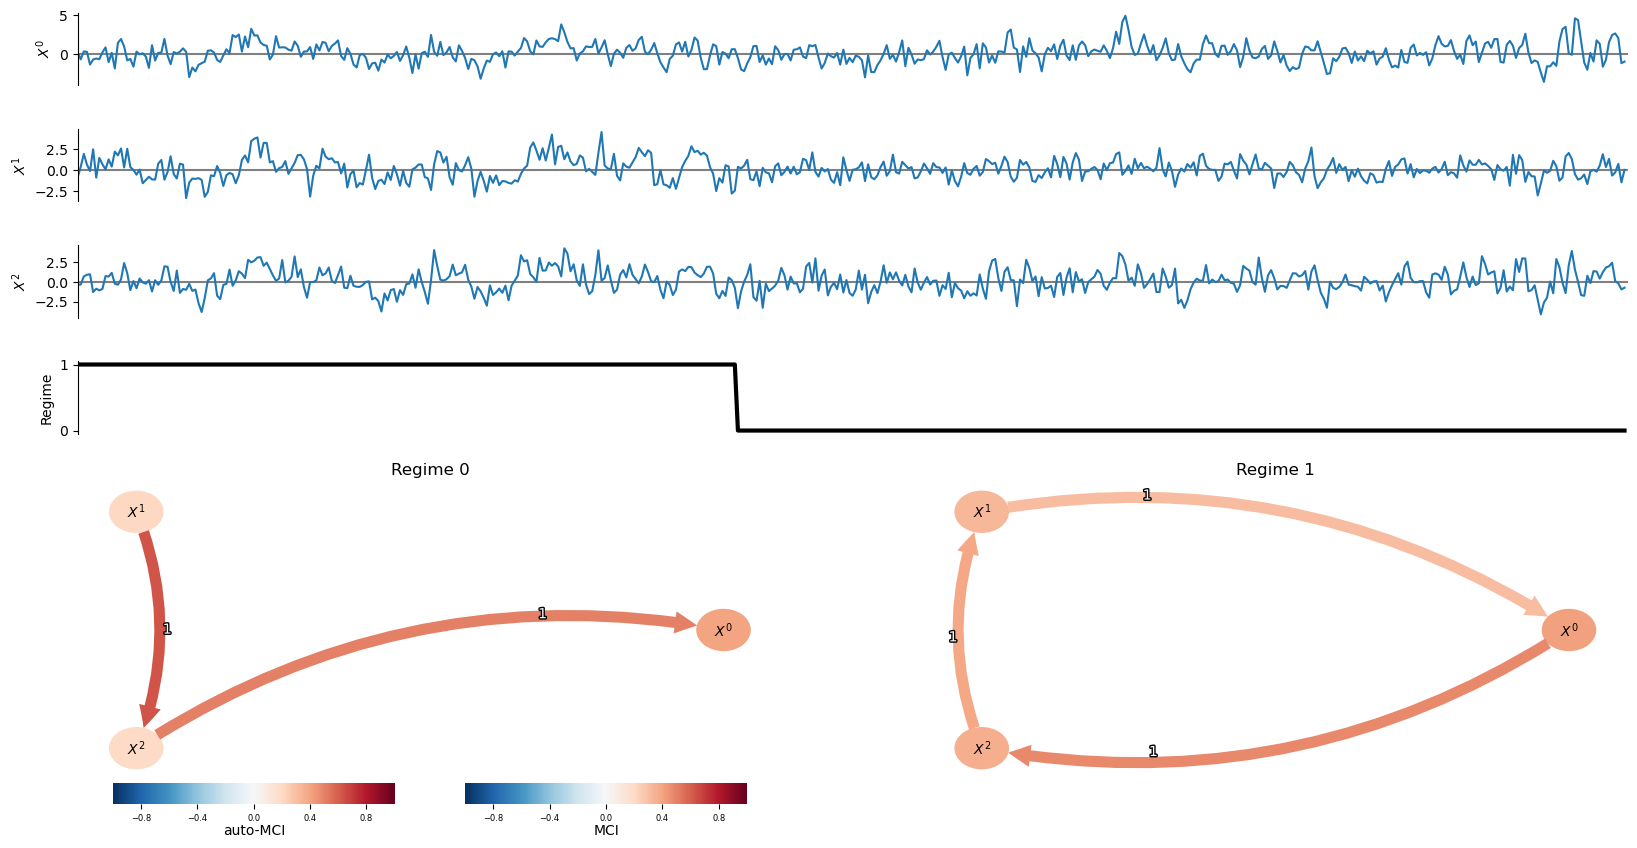

In [38]:
regimes = results['regimes'].argmax(axis=0)
n_regimes = len(results['causal_results'])

T = 500
datatime = datatime[:T]
data = data[:T]

# Create nice Mosaic plot
mosaic = [['data %s' %j for i in range(n_regimes)] for j in range(N+1)]
for n in range(N):
    mosaic.append(['graph %s' %i for i in range(n_regimes)])

fig, axs = plt.subplot_mosaic(mosaic = mosaic, figsize=(20, 10))

for j in range(N):
    ax = axs['data %s' %j]
    ax.axhline(0., color='grey')
    ax.plot(datatime, data[:,j])
    for loc, spine in ax.spines.items():
        if loc != 'left':
            spine.set_color("none")
    
    ax.xaxis.set_ticks([])   
    ax.set_xlim(0., T)
    ax.set_ylabel(var_names[j])
    
# Regime variable
ax = axs['data %s' %N]
ax.plot(datatime, regimes.astype('int'), lw=3, color='black')
for loc, spine in ax.spines.items():
    if loc != 'left':
        spine.set_color("none")
ax.xaxis.set_ticks([]) 
ax.yaxis.set_ticks(range(n_regimes))   
ax.set_xlim(0., T)
ax.set_ylabel("Regime")
    
# Causal graphs for each regime
for w in range(n_regimes):
    if w == 0: show_colorbar=True
    else: show_colorbar = False
    tp.plot_graph(graph=results['causal_results'][w]['graph'], 
                  val_matrix=results['causal_results'][w]['val_matrix'], 
                  show_colorbar=show_colorbar,
                  var_names=var_names,
                  fig_ax=(fig, axs['graph %s' %w]))
    axs['graph %s' %w].set_title("Regime %d" %w, pad=-4)

fig.subplots_adjust(hspace=0.6)
plt.show()

In [61]:
#-- causal structures estimated with RPCMCI for each regime
causal_structures = {
    # Regime 0
    0: {
        "X0": [(0, -1), (2,-1)],
        "X1": [(1, -1)],
        "X2": [(2, -1), (1, -1)],
        
    },
    # Regime 1
    1: {
        "X0": [(0, -1),(1,-1)],
        "X1": [(1, -1),(2,-1)],
        "X2": [(2, -1), (0, -1)],
    }
}

In [58]:
# add the estimate regimes from rpcmci and the true regimes for the test data
df["regime"] = np.concatenate((regimes, true_regime[500:]))

In [60]:
df.to_csv("simulated_time_series2.csv")